# Homework 1 Part 1 - Solutions

---

# Exercise 1 (3 points)

> **The Bias-Variance Trade-Off**
> 
> In model evaluation, **bias** refers to error introduced by overly simplistic assumptions, which can cause **underfitting**, while **variance** refers to sensitivity to fluctuations in the training data, which can cause **overfitting**. **High-bias** models may perform poorly on both training and validation data, whereas **high-variance** models may fit training data very well but generalize poorly to unseen data. Cross-validation helps reveal and balance these effects by testing the model on multiple splits of the data.

**You are fitting a polynomial regression model to data generated by $t=f(x) + \epsilon$, where $f(x)$ is smooth and $\epsilon\sim \mathcal{G}(0,\sigma^2)$. Consider two candidate models:**

* **Model A: Degree-3 polynomial, estimated training MSE = 2.1, estimated 10-fold CV MSE = 2.4.**

* **Model B: Degree-12 polynomial, estimated training MSE = 0.8, estimated 10-fold CV MSE = 3.1.**

1. (1.5 points) **Explain which model exhibits higher variance and why.**

Based on the information provided, a model with high-variance and low-bias is verfitting, and a model with low-variance and high-bias is underfitting. A *good* model seeks to find a trade-off between minimizing variance and minimizing bias.


Model A performance in training and validation are closer, suggesting that the model is not overfitting. Model B has a much lower MSE in training than validation, suggesting the model is overfitting and not generalizing well to the validation set. Thus, model B exhibits higher variance.

2. (1.5 points) **Which model would you deploy? Justify your choice using the bias–variance trade-off and any other relevant principles.**

As stated before, a *good* model seeks to find a trade-off between minimizing variance and minimizing bias. Even hough model B has better performance in training, it has a much worse performance in validation, the set of interest. Thus, given these two choices, model A would be preferred.

---

# Exercise 2 (2.5 points)

**You fit ridge regression with $\lambda\in\{0.01, 0.1, 1, 10\}$ using 5-fold cross-validation. The table below lists the mean absolute error on each fold.**
 
|Fold | 0.01 | 0.1 | 1 | 10 |
| -- | -- | -- | -- | -- |
|1 | 1.9 | 1.8 | 1.7 | 2.0 |
|2 | 2.0 | 2.0 | 1.8 | 2.2 |
|3 | 2.1 | 2.5 | 2.6 | 2.4 |
|4 | 2.2 | 1.9 | 1.9 | 2.1 |
|5 | 2.3 | 2.1 | 1.8 | 2.3 |

1. (1 point) **Pick the best $\lambda$ using the average validation error.**

We can select the value for $\lambda$ that **minimizes** (1) the average MAE in the 5 folds, or (2) the largest MAE (worst) performance. The performance for each $\lambda$ is as follows:

 
|Fold | 0.01 | 0.1 | 1 | 10 |
| -- | -- | -- | -- | -- |
|1 | 1.9 | 1.8 | 1.7 | 2.0 |
|2 | 2.0 | 2.0 | 1.8 | 2.2 |
|3 | 2.1 | 2.5 | 2.6 | 2.4 |
|4 | 2.2 | 1.9 | 1.9 | 2.1 |
|5 | 2.3 | 2.1 | 1.8 | 2.3 |
|avg | 2.1 | 2.06 | 1.96 | 2.2 |
| min-max | 2.3 | 2.5 | 2.6 | 2.4 |

Using the average performance, the best $\lambda$ would be $\lambda=1$.

2. (1 point) **Pick the best $\lambda$ using the min–max strategy (i.e. maximize worst-case performance).**

Based on the table above, and using the min-max approach, the selected $\lambda$ would also be $\lambda=0.01$.

3. (0.5 pointt) **Briefly discuss the trade-offs between these two strategies.**

The average validation rule aims to minimize the expected error, while the min-max rule minimizes the largest fold error to guard against worst-case scenarios. The average strategy generally yields the most accurate model overall but can overlook a single difficult or outlier fold. In contrast, the min–max approach provides stronger robustness and fairness across all folds. The choice depends on whether overall accuracy or worst-case reliability is more important for the application.

---

# Exercise 3 (7.5 points)

**Suppose you have a training set with $N$ data points $\{x_i\}_{i=1}^N$, where $x_i\in\mathbb{R}^+$ (set of positive real numbers). Assume the samples are independent and identically distributed (i.i.d.), and each sample is drawn from a Gamma random variable with probability density function:**

\begin{align*}
    p(x|\alpha, \beta) = \frac{\beta^{\alpha}}{\Gamma(\alpha)}x^{\alpha-1}e^{-\beta x}
\end{align*}

**where $\alpha,\beta>0$.**

**Moreover, consider another Gamma density as the prior probability on the hyperparameter $\beta$,**

\begin{align*}
    p(\beta|a,b) = \frac{b^a}{\Gamma(a)}\beta^{a-1}e^{-b \beta}
\end{align*}

**where $a,b>0$.**

**Answer the following questions:**

1. (2.5 points) **Derive the maximum likelihood estimate (MLE) for the parameter $\beta$. Show your work.**

The observed data likelihood for MLE is:

\begin{align*}
    \mathcal{L}^0 = \prod_{i=1}^N \frac{\beta^{\alpha}}{\Gamma(\alpha)}x_i^{\alpha-1}e^{-\beta x_i}
\end{align*}

The log-likelihood is given by:

\begin{align*}
    \mathcal{L} &= \ln{\mathcal{L}^0} = \sum_{i=1}^N \left[\ln\left(\frac{\beta^{\alpha}}{\Gamma(\alpha)}\right) + (\alpha-1) \ln(x_i) -\beta x_i \right]\\
    &= \sum_{i=1}^N \left[\alpha\ln(\beta) -\ln(\Gamma(\alpha)) + (\alpha-1) \ln(x_i) -\beta x_i  \right]
\end{align*}

We can now find the MLE estimation for $\beta$:

\begin{align*}
    \frac{\partial \mathcal{L}}{\partial \beta} = 0 \iff \sum_{i=1}^N \left[ \frac{\alpha}{\beta} - x_i \right] = 0 \iff N\frac{\alpha}{\beta} - \sum_{i=1}^N x_i = 0 \iff \beta = \frac{N\alpha}{\sum_{i=1}^N x_i}
\end{align*}

2. (2.5 points) **Derive the maximum a posteriori (MAP) estimate for the parameter $\beta$. show your work.**

The observed data likelihood for MAP is:

\begin{align*}
    \mathcal{L}^0 &= \left(\prod_{i=1}^N \frac{\beta^{\alpha}}{\Gamma(\alpha)}x_i^{\alpha-1}e^{-\beta x_i}\right)\frac{b^a}{\Gamma(a)}\beta^{a-1}e^{-b \beta}\\
    &\propto \left(\prod_{i=1}^N \beta^{\alpha}e^{-\beta x_i}\right)\beta^{a-1}e^{-b \beta}\\
    &= \beta^{\sum_{i=1}^N \alpha} e^{-\beta\sum_{i=1}^N x_i}\beta^{a-1}e^{-b \beta}\\
    &=\beta^{(N\alpha+a)-1} e^{-\beta\left(\sum_{i=1}^N x_i +b\right)}
\end{align*}

The log-likelihood is given by:

\begin{align*}
    \mathcal{L} &= \ln{\mathcal{L}^0} = (N\alpha+a-1) \ln(\beta) -\beta\left(\sum_{i=1}^N x_i +b\right)
\end{align*}

We can now find the MAP estimation for $\beta$:

\begin{align*}
    \frac{\partial \mathcal{L}}{\partial \beta} = 0 &\iff (N\alpha+a-1)\frac{1}{\beta} - \left(\sum_{i=1}^N x_i +b\right) = 0\\
    & \iff \beta = \frac{N\alpha +a-1}{\sum_{i=1}^N x_i +b}
\end{align*}

3. (2.5 points) **Does a Gamma-Gamma form a conjugate prior for the parameter $\beta$? Why or why not? If yes, write down the pseudo-code for the online update of the prior parameters (including the equations for the new parameters of the prior). Justify with your own work.**

Yes, the Gamma distribution forms a conjugate prior because the shape of the posterior probability is proportionally equal to the prior probability.

The pseudo-code for online update of the prior is as follows:

1. Start at iteration $t=0$. Initialize the prior parameters $a^{(t)}$ and $b^{(t)}$.

2. Compute the parameter estimation for the current prior probability:
\begin{align*}
    \beta_{\text{MAP}} = \frac{N\alpha +a^{(t)}-1}{\sum_{i=1}^N x_i +b^{(t)}}
\end{align*}

3. Update the prior parameters
\begin{align*}
    a^{(t+1)} &\leftarrow a^{(t)} +N\alpha \\
    b^{(t+1)} &\leftarrow b^{(t)} + \sum_{i=1}^N x_i
\end{align*}
   
4. Increment iteration counter
\begin{align*}
    t \leftarrow t+1
\end{align*}

---

# Exercise 4 (7.5 points)

**An electronics engineer is testing a batch of microchips. Each microchip either works correctly (success or 1) or fails (failure or 0) when powered on. Let $x_i\in\{0,1\}$ represent whether microship $i$ is working. Suppose the engineer tests $N$ microchips from the batch, and the probability that a single microchip works correctly is $p$.**

**Answer the following questions:**
1. (2 points) **Which random variable (RV) best describes this data (assumme $x_i$'s, are i.i.d.)? For your choice of RV, write down the observed data likelihood, $\mathcal{L}$.**

Let $X$ be the random variable to model the number of working microships in a batch of $N$. This RV is best modeled with a Binomial random variable with $N$ number of samples and $p$ is the success probability.

The observed data likelihood can be written as:

\begin{align*}
\mathcal{L}^0 = \binom{N}{k} p^k (1-p)^{N-k}
\end{align*}

where $k$ is the number of working microships, defined as $k=\sum_{i=1}^N x_i$.

2. (3 points) **Assume the prior $p\sim\text{Beta}(\alpha,\beta)$, i.e.**

$$P(p|\alpha, \beta)=\frac{\Gamma(\alpha+\beta)}{\Gamma(\alpha)\Gamma(\beta)}p^{\alpha-1}(1-p)^{\beta-1}$$

**Derive the MAP estimate of $p$**.

The observed data likelihood for MAP is:

\begin{align*}
    \mathcal{L}^0 &= \binom{N}{k} p^k (1-p)^{N-k}\frac{\Gamma(\alpha+\beta)}{\Gamma(\alpha)\Gamma(\beta)}p^{\alpha-1}(1-p)^{\beta-1}\\
    &= \frac{\Gamma(\alpha+\beta)}{\Gamma(\alpha)\Gamma(\beta)} p^{k+\alpha-1} (1-p)^{N-k+\beta-1}\\
    &\propto p^{k+\alpha-1} (1-p)^{N-k+\beta-1}
\end{align*}

The log-likelihood is given by:

\begin{align*}
    \mathcal{L} &= \ln{\mathcal{L}^0} = (k+\alpha-1)\ln(p) + (N-k+\beta-1)\ln(1-p)
\end{align*}

We can now find the MAP estimation for $\beta$:

\begin{align*}
    \frac{\partial \mathcal{L}}{\partial \beta} = 0 &\iff (k+\alpha-1)\frac{1}{p} - (N-k+\beta-1)\frac{1}{1-p}= 0\\
    & \iff (1-p)(k+\alpha-1) - p (N-k+\beta-1) = 0\\
    & \iff k+\alpha-1 - kp -\alpha p + p - pN +pk -p\beta+p = 0\\
    & \iff p = \frac{k+\alpha-1}{N+\alpha+\beta -2}
\end{align*}

3. (1 point) **Provide the sequential update equations for $\alpha$ and $\beta$.**

The Binomial-Beta form a conjugate prior because the shape of the posterior probability is proportionally equal to the prior probability, also a Beta distribution.

The pseudo-code for online update of the prior is as follows:

1. Start at iteration $t=0$. Initialize the prior parameters $\alpha^{(t)}$ and $\beta^{(t)}$.

2. Compute the parameter estimation for the current prior probability:
\begin{align*}
    p_{\text{MAP}} = \frac{\sum_{i=1}^Nx_i+\alpha^{(t)}-1}{N+\alpha^{(t)}+\beta^{(t)}-2}
\end{align*}

4. Update the prior parameters
\begin{align*}
\alpha^{(t+1)} &\leftarrow \alpha^{(t)} + \sum_{i=1}^N x_i\\
\beta^{(t+1)} &\leftarrow \beta^{(t)} +N -\sum_{i=1}^N x_i
\end{align*}
   
6. Increment iteration counter
\begin{align*}
    t \leftarrow t+1
\end{align*}

4. (1 points) **If $\alpha=2$, $\beta=3$, $N=20$, and 11 microships were working correctly, compute the posterior mean of $p$.**

Intuition: Since a little more than half of the microships are working (11 out of 20), then the most likely probability of success, $p$ is a little over 50%.

From part (2), we see that the posterior is also a Beta distribution with parameters $\alpha_2$ and $\beta_2$, defined as $\alpha_2 = \alpha + \sum_{i=1}^N x_i$ and $\beta_2= \beta + N -\sum_{i=1}^N x_i$. Thus, we have

\begin{align*}
p &\sim \text{Beta}\left(\alpha + \sum_{i=1}^N x_i, \beta + N -\sum_{i=1}^N x_i\right)\\
&\sim \text{Beta}\left(2 + 11, 3 + 20-11\right)\\
&\sim \text{Beta}\left(13, 12\right)
\end{align*}

The mean of a Beta distribution, by definition, is $E[p] = \sum_i x_i \text{Beta}(x_i|13,12) = \frac{13}{13+12}=0.52 $. As expected.

---

# Exercise 5 (7.5 points)

**Suppose you have a training set with $N$ data points $\{x_i\}_{i=1}^N$ with $x_i\in \mathbb{R}$. Assume the samples are independent and identically distributed (i.i.d.), and each sample is drawn from a (univariate) Gaussian density function with _known_ variance $\sigma^2$, i.e. $P(x|\mu) \sim \mathcal{N}(\mu,\sigma^2)$.**

**Consider another Gaussian density function as the prior probability on the mean $\mu$ parameter, $P(\mu) \sim \mathcal{N}(\mu_0,\sigma_0^2)$.**

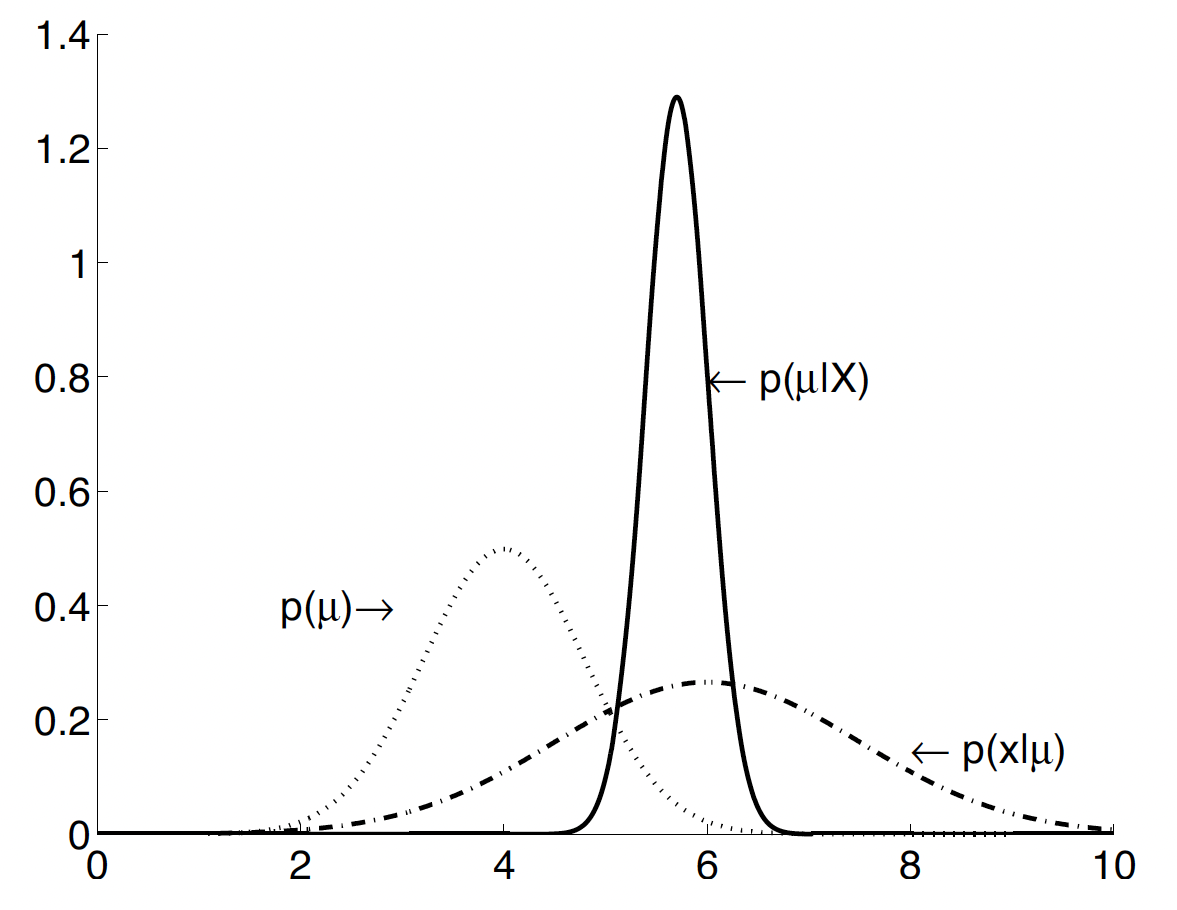

In [2]:
from IPython.display import Image
Image('figures/parameter_estimation.png', width=450)

**Assume $P(x|\mu) \sim \mathcal{N}(\mu=6,\sigma^2=1.5^2)$ and $P(\mu) \sim \mathcal{N}(\mu_0=4,\sigma_0^2=0.8^2)$, ant the resulting posterior probability on $\mu$ to be $p(\mu|x)\sim\mathcal{N}(5.7, 0.3^2)$. The figure above illustrates all distributions involved.**

**Answer the following questions:**
1. (2.5 points) **Based on the information provided, what is the value of $\mu$ that _should_ be selected using the MAP approach?**

All the information is provided in the problem statement. Using the MAP approach, we optimize (maximize) the **posterior** probability, which is a Gaussian with mean 5.7 and variance 0.09. Since Gaussian is symmetric with respect to the mean, and its mean is the most likely value, then the selected value for $\mu$ is 5.7. 

2. (2.5 points) **How would the solution for $\mu$ (from (1)) change as $\sigma_0$ becomes very small?**

As the variance, $\sigma_0^2$, for the prior on $\mu$ changes, so will the resulting posterior parameters. If $\sigma_0^2$ is very small, then the prior encodes a strong belief that $\mu$ is 4. In the limit, when $\sigma_0^2 \rightarrow 0$, the resulting posterior will be centered at $\mu=4$.

3. (2.5 points) **How would the solution for $\mu$ (from (1)) change as $\sigma_0$ becomes very large?**

If $\sigma_0^2$ is very large, then the prior encodes a weak belief on. In the limit, when $\sigma_0^2 \rightarrow +\infty$, the resulting posterior will be primarily informed by the data, and thus it will be centered at $\mu=6$.

---

# Exercise 6 (3 points)

**The figure below, shows how the weights associated with each with the 10 attributes/features change as a function of the regularizer parameter $\lambda$ in a linear regression model.**

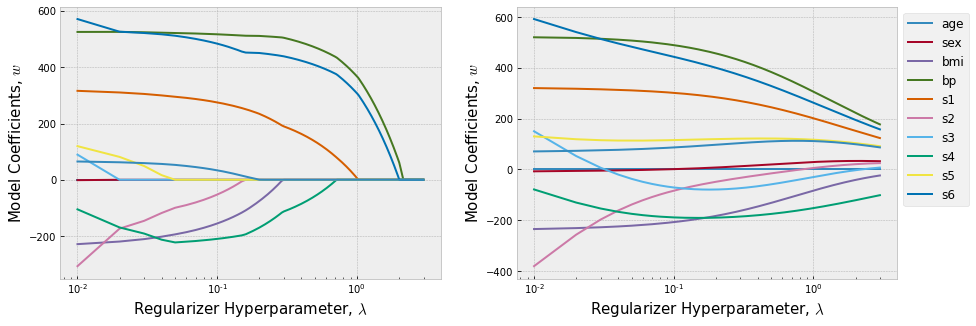

In [3]:
from IPython.display import Image
Image('figures/Regression_with_Regularizer.png', width=900)

**Based on this plots, which one (left or right) corresponds to the Ridge Regression and Lasso Regression? Justify your answer.**

We see that on the plot in the left, as the regularizer hyperparameter $\lambda$ increases, the coefficients $w_j$ converge to exactly 0. Thus the vector of coefficients, $\mathbf{w}$, will be sparse. This is a particular characteristic of the Lasso regularizer. Thus, ridge regularizer, corresponds to the plot on the right, where we see that the parameters $\mathbf{w}$ are decreasing in value as $\lambda$ increases but never reaching exactly 0.

---

# Exercise 7 (2 points)

**In practice, when you are implementing your regression or classification tasks with your feature matrix $\mathbf{X}$ of size $N\times M$, $N$ is the number of training samples and $M$ is the number of dimensions/features.**

**If you encounter the computational error "matrix is singular":**

1. (1 point) **What does this mean about the feature matrix $\mathbf{X}$?**
2. (1 point) **What should you do to solve the problem?**

1. It means the matrix is not invertible because its determinant is equal to zero. A singular matrix has at least one eigenvalue equal to 0 which occurs when features are co-linear.
2. We should diagonally load the matrix before inverting it, or eliminate the co-linear feature/s.

---

# Exercise 8 (2 points)

**Before feeding the data to a mapper function, we must carry any necessary preprocessing. This may include encoding features, dealing with missing values, and scaling. In which order should the data be processed:**

* **Option 1: Partition the data into training-test sets, then apply preprocessing based on training set.**

* **Option 2: Apply preprocessing on entire data, then partition into training-test sets.**

Option 1 is correct. The data must be **split into training-test first**. 

If you preprocess the data first with the entire dataset, this will introduce bias in your results (good validation performances but poor results during deployment). This introduces bias because when you build the encoder transformer on the entire dataset, it will contain information about the samples that will be used in the test set. This is also referred to as **data leakage**.

---

# Exercise 9 (4 points)

**Answer the following questions:**

1. (1 point) **Interpret an L2-penalty as a Bayesian prior.**

2. (1 point) **Describe how this perspective enables online updating.**

3. (1 point) **State one advantage for hyperparameter selection.**

4. (1 point) **Give a real-world example where sampling from the posterior is preferable to a point estimate.**

1. The Bayesian interpretation of the objective function provides a different perspective of the optimization problem. Put simply, it illustrates how the least squares objective function with a regularizer penalty term is equivalent to the Maximum A Posteriori (MAP) point estimation, where the data likelihood and prior probability have a specific probabilistic model. An L2-penalty, or **ridge**, assumes a Gaussian prior belief with mean zero and variance $1/\lambda$.

This interpretation allows us to think about the objective function in the Bayesian sense, thus now we can pick any probabilistic model for the data likelihood and prior distributions, those that fit the data better (alleviating Gaussianity assumptions), as well as encoding prior beliefs that fit the problem better.

2. With the Bayesian interpretation, we are able to make online updates of the prior distributions provided that we are working with a conjugate prior relationship. This online update would not be possible with the "objective function interpretation", because it would require us to hard-code the penalty term. But in the Bayesian interpretation, we are able to start with a non-informative or incorrect prior and update it as we collect more data.

3. The Bayesian interpretation provides a principled method for hyperparameter selection rather than relying only on manual tuning or cross-validation. Knowing that the L2-penalty has a variance of $1/\lambda$, we could (1) estimate it from data, using another MAP approach, or (2) adding another prior encoding values for $\lambda$.

4. For medical applications, and many others, rather than predicting, for example, patient survival as "yes" or "no", we can use the posterior to estimate a confidence interval on the probability of patient survival.

---

# Exercise 10 (6 points)

**Consider a labeled training set $\{(x_i,t_i)\}_{i=1}^N$, where $x_i\in\mathbb{R}$ and $t_i\in\mathbb{R}$. Let the data likelihood on $t_i$ be a univariate Gaussian distribution, that is,**

\begin{align*}
P(t_i|\mathbf{w}) \sim G(t_i | y_i, 1)\;\; \text{ where }\;\; y_i=y(x_i)=\phi(x_i)^T\mathbf{w}
\end{align*}

**Consider the prior probability on parameter $\mathbf{w}$ to be a multivariate Gaussian distributed with mean $\mathbf{0}$ and isotropic covariance matrix $\beta^2\mathbf{I}$. Find the MAP solution for the parameter $\mathbf{w}$. Show your work.**

The MAP solution for the parameter $\mathbf{w}$ can be found by finding the point estimate that maximizes the log-likelihood $\mathcal{L} = \ln \mathcal{L}^0$. Let's first write down the observed data likelihood $\mathcal{L}^0$:

\begin{align*}
\mathcal{L}^0 =& \left(\prod_{i=1}^N G(t_i|y_i,1)\right)G(\mathbf{w}|\mathbf{0},\beta^2\mathbf{I})\\
=& \left(\prod_{i=1}^N (2\pi)^{-1/2} \exp\left(-\frac{(t_i-y_i)^2}{2}\right) \right)(2\pi)^{-d/2}|\beta^2\mathbf{I}|^{-1/2}\exp\left(-\frac{\mathbf{w}^T\mathbf{w}}{2\beta^2}\right)
\end{align*}

Now, we can find the log-likelihood:

\begin{align*}
\mathcal{L} =& \ln \mathcal{L}^0 = -\frac{N}{2}\ln(2\pi) - \sum_{i=1}^N \frac{1}{2}(t_i - y_i)^2 -\frac{d}{2}\ln(2\pi) -\frac{d}{2}\ln(\beta^2) - \frac{\mathbf{w}^T\mathbf{w}}{2\beta^2}\\
=& -\frac{N}{2}\ln(2\pi) - \frac{1}{2}(\mathbf{t} - \mathbf{X}\mathbf{w})^T(\mathbf{t} - \mathbf{X}\mathbf{w}) -\frac{d}{2}\ln(2\pi) -\frac{d}{2}\ln(\beta^2) - \frac{\mathbf{w}^T\mathbf{w}}{2\beta^2}\\
=& -\frac{N}{2}\ln(2\pi) - \frac{1}{2}(\mathbf{t}^T\mathbf{t} - \mathbf{t}^T\mathbf{X}\mathbf{w} - \mathbf{w}^T\mathbf{X}^T\mathbf{t} + \mathbf{w}^T\mathbf{X}^T\mathbf{X}\mathbf{w}) \\
& \qquad\qquad\qquad\qquad -\frac{d}{2}\ln(2\pi) -\frac{d}{2}\ln(\beta^2) - \frac{\mathbf{w}^T\mathbf{w}}{2\beta^2}
\end{align*}

Now, we find the solution for $\mathbf{w}$:

\begin{align*}
\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = 0 \iff & \frac{1}{2} (2\mathbf{t}^T\mathbf{X} - 2\mathbf{w}^T\mathbf{X}^T\mathbf{X}) - 2 \frac{\mathbf{w}^T}{2\beta^2} =0\\
\iff & \mathbf{X}^T\mathbf{X}\mathbf{w} + \frac{\mathbf{w}}{\beta^2} = \mathbf{X}^T\mathbf{t}\\
\iff & \mathbf{w}_{\text{MAP}} = \left(\mathbf{X}^T\mathbf{X}+\frac{\mathbf{I}}{\beta^2}\right)^{-1}\mathbf{X}^T\mathbf{t}
\end{align*}

---